# Replicate Aggregation / Censoring — Distributional Analysis

Companion analysis to `CENSORING_ANALYSIS.md` (repo root), addressing **Reviewer #1 comment 1**
and **Reviewer #3 comments 1-2** from the round-2 review: how repeated replicate yield
measurements get collapsed into a single class label before every downstream step (network
construction, pilot selection, label propagation).

**This notebook intentionally does not use `src/dataset.py`.** That module's aggregation step
currently has an unrelated implementation bug (see `CENSORING_ANALYSIS.md`) pending a fix from
a collaborator. Everything below is rebuilt directly from the raw plate CSVs in `data/`, so this
analysis doesn't need to wait on that fix.

**Plan** (mirrors `CENSORING_ANALYSIS.md`, "Where we're aiming", points 2-6):

2. Rebuild the fully raw, uncollapsed dataset directly from `data/*.csv`.
3. Define a small family of candidate aggregation/censoring rules.
4. Visualize the resulting yield distributions and quantify contrast at the
   moderate-vs-marginal reactivity boundary — not the tails, which are rule-invariant.
5. Let the class threshold float with the aggregation rule instead of fixing 20%/40% a priori.
6. Propagate each rule downstream (pilot-set stability, per-core label-propagation AUPRC).

A short summary and conclusion close out the notebook.


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.signal import argrelextrema
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import average_precision_score
from itertools import product
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110
RNG = np.random.default_rng(42)


## 2. Rebuild the raw, uncollapsed dataset

We reproduce `dataset.py`'s data-loading and core/BB-identification logic (which is *not* in
dispute) but stop **before** its aggregation step, keeping every raw replicate. We also
replicate its handling of substrate pairs that were tested in both plate `008b` and plates
`010-013` under adjusted stoichiometry: for those pairs, only the `010-013` replicates are kept,
matching the original code's `substrates_in_8_to_12` logic.


In [40]:
DATA_DIR = "../data"  # this notebook lives in src/

RAW_FILES = {
    "008b": f"{DATA_DIR}/008b_final_report.csv",
    "010": f"{DATA_DIR}/010_final_report.csv",
    "011": f"{DATA_DIR}/011_final_report.csv",
    "012": f"{DATA_DIR}/012_final_report.csv",
    "013": f"{DATA_DIR}/013_final_report.csv",
}

cols_8b = ["reactant_1&name", "reactant_1&smiles", "reactant_2&name", "reactant_2&smiles",
           "catalyst_1&name", "base_1&name", "solvent_2&name", "suzuki_product_CAD_yield"]
cols_main = ["reactant_1&name", "reactant_1&smiles", "reactant_2&name", "reactant_2&smiles",
             "suzuki_product_CAD_yield"]

df_8b = pd.read_csv(RAW_FILES["008b"], usecols=cols_8b)
df_8b = df_8b[(df_8b["catalyst_1&name"] == "XPhos Pd G4") & (df_8b["solvent_2&name"] == "dioxane")]
df_8b = df_8b[cols_main].copy()
df_8b["plate"] = "008b"

frames = [df_8b]
for plate in ["010", "011", "012", "013"]:
    d = pd.read_csv(RAW_FILES[plate], usecols=cols_main)
    d["plate"] = plate
    frames.append(d)

raw_df = pd.concat(frames, ignore_index=True)
raw_df = raw_df.rename(columns={"reactant_1&smiles": "core_smiles", "reactant_2&smiles": "bb_smiles"})
raw_df["yield"] = raw_df["suzuki_product_CAD_yield"].astype(float)
print(f"Raw well-level rows loaded across all 5 plates: {len(raw_df)}")
raw_df.head()


Raw well-level rows loaded across all 5 plates: 1604


,reactant_1&name,core_smiles,reactant_2&name,bb_smiles,suzuki_product_CAD_yield,plate,yield
0,1-(4-bromo-2-methylphenyl)pyrrolidin-2-one,CC1=C(N2CCCC2=O)C=CC(Br)=C1,417706695,CCc1ccc(B(O)O)cc1,10.977478,008b,10.977478
1,1-(4-bromo-2-methylphenyl)pyrrolidin-2-one,CC1=C(N2CCCC2=O)C=CC(Br)=C1,417716027,OB(O)c1cccc2ccccc12,18.110530,008b,18.110530
2,"5-bromo-3-methyl-3,4-dihydropyrimidin-4-one",CN1C=NC=C(C1=O)Br,417706695,CCc1ccc(B(O)O)cc1,3.449698,008b,3.449698
3,"5-bromo-3-methyl-3,4-dihydropyrimidin-4-one",CN1C=NC=C(C1=O)Br,417716027,OB(O)c1cccc2ccccc12,27.351879,008b,27.351879
4,1-(4-bromo-2-methylphenyl)pyrrolidin-2-one,CC1=C(N2CCCC2=O)C=CC(Br)=C1,417385164,COc1ccc(B2OC(C)(C)C(C)(C)O2)cc1F,9.820978,008b,9.820978


In [41]:
# Identify the 13 cores (halides surveyed against all 69 BBs) and the 69 BBs, excluding PhBr
core_counts = raw_df.groupby("core_smiles")["bb_smiles"].nunique()
core_smiles_list = sorted(core_counts[core_counts >= 69].index.tolist())
PHBR = "BrC1=CC=CC=C1"
core_smiles_list = [c for c in core_smiles_list if c != PHBR]
bb_smiles_list = sorted(raw_df[raw_df["core_smiles"] == core_smiles_list[0]]["bb_smiles"].unique().tolist())

print(f"Cores identified: {len(core_smiles_list)} (expect 13)")
print(f"Building blocks identified: {len(bb_smiles_list)} (expect 69)")


Cores identified: 13 (expect 13)
Building blocks identified: 69 (expect 69)


In [42]:
# Replicate the 008b/010-013 stoichiometry-adjustment special case:
# for pairs tested in BOTH 008b and 010-013, keep only the 010-013 replicates.
core_bb_pairs = pd.DataFrame(list(product(core_smiles_list, bb_smiles_list)),
                              columns=["core_smiles", "bb_smiles"])
valid_pairs = set(map(tuple, core_bb_pairs.values))

plate8b_pairs = set(map(tuple, raw_df[raw_df["plate"] == "008b"][["core_smiles", "bb_smiles"]]
                         .drop_duplicates().values))
pair_plate_counts = raw_df.groupby(["core_smiles", "bb_smiles"])["plate"].nunique()

overlap_pairs = {p for p in plate8b_pairs if p in valid_pairs and pair_plate_counts.get(p, 0) > 1}
print(f"Substrate pairs tested in both 008b and 010-013 (stoichiometry-adjusted overlap): {len(overlap_pairs)}")

records = []
for core, bb in core_bb_pairs.itertuples(index=False):
    sub = raw_df[(raw_df["core_smiles"] == core) & (raw_df["bb_smiles"] == bb)]
    if (core, bb) in overlap_pairs:
        sub = sub[sub["plate"].isin(["010", "011", "012", "013"])]
    for _, row in sub.iterrows():
        records.append((core, bb, row["plate"], row["yield"]))

raw_long = pd.DataFrame(records, columns=["core_smiles", "bb_smiles", "plate", "yield"])
rep_counts = raw_long.groupby(["core_smiles", "bb_smiles"]).size()

print(f"Total raw replicate rows in the 13x69 matrix: {len(raw_long)}")
print(f"Unique substrate pairs: {rep_counts.shape[0]} (manuscript reports 897)")
print("\nReplicate-count distribution:")
print(rep_counts.value_counts().sort_index())
print(f"\nPairs tested >=2 times: {(rep_counts >= 2).sum()} (manuscript reports 409)")
print(f"Pairs tested >=3 times: {(rep_counts >= 3).sum()} (manuscript reports 131)")


Substrate pairs tested in both 008b and 010-013 (stoichiometry-adjusted overlap): 2
Total raw replicate rows in the 13x69 matrix: 1420
Unique substrate pairs: 897 (manuscript reports 897)

Replicate-count distribution:
1     537
2     245
3     108
7       5
17      2
Name: count, dtype: int64

Pairs tested >=2 times: 360 (manuscript reports 409)
Pairs tested >=3 times: 115 (manuscript reports 131)


**Total pair count matches exactly** (897), which is what matters for the classification
comparisons below. The replicate-*count* distribution is a partial match, not exact: the
manuscript reports 409 pairs tested more than once (131 three-plus times); this rebuild finds
360 and 115. The most likely source of the gap is plate `008b`'s internal structure — a few
"control" substrate pairs appear to have been re-tested many times within `008b` itself (up to
17x for two pairs) as part of the condition-screening process described in the manuscript, and
the `008b`-vs-`010-013` overlap rule implemented above only catches pairs that *also* appear in
010-013, not ones over-represented within `008b` alone. This is flagged here rather than
silently absorbed; it does not affect the total-pair-count match, and every rule below is applied
to the exact same replicate sets, so the *relative* comparison across rules is unaffected.


## 3. Candidate aggregation / censoring rules

Five point-estimate rules, applied per (core, BB) group of raw replicate yields. We keep
`first_replicate` in the comparison as a reference point — it's what the repo's current, buggy
`dataset.py` actually returns — not as a proposed option.


In [43]:
def rule_positive_only_median(yields):
    """Current stated rule: median of non-zero replicates, 0 if all are zero."""
    pos = yields[yields > 0]
    return np.median(pos) if len(pos) else 0.0

def rule_all_replicate_median(yields):
    """Alternative: median across all replicates, zeros included."""
    return np.median(yields)

def rule_mean_all(yields):
    """Alternative: mean across all replicates, zeros included."""
    return np.mean(yields)

def rule_max_replicate(yields):
    """Alternative: 'did it ever work' — the best observed replicate."""
    return np.max(yields)

def rule_first_replicate(yields):
    """Reference only: what the repo's current dataset.py bug actually returns."""
    return yields[0]

RULES = {
    "positive_only_median": rule_positive_only_median,
    "all_replicate_median": rule_all_replicate_median,
    "mean_all": rule_mean_all,
    "max_replicate": rule_max_replicate,
    "first_replicate (current repo bug)": rule_first_replicate,
}

agg = (raw_long.groupby(["core_smiles", "bb_smiles"])["yield"]
       .apply(lambda s: np.array(s.values)).reset_index())
agg = agg.rename(columns={"yield": "replicate_yields"})

for name, fn in RULES.items():
    agg[name] = agg["replicate_yields"].apply(fn)

# Supplementary confidence signal (Reviewer #3's "replicate-confidence flag" suggestion),
# reported alongside the point estimates rather than folded into them.
agg["n_replicates"] = agg["replicate_yields"].apply(len)
agg["frac_positive"] = agg["replicate_yields"].apply(lambda y: np.mean(np.array(y) > 0))

print(f"Aggregated table: {agg.shape[0]} substrate pairs")
agg.head()


Aggregated table: 897 substrate pairs


,core_smiles,bb_smiles,replicate_yields,positive_only_median,all_replicate_median,mean_all,max_replicate,first_replicate (current repo bug),n_replicates,frac_positive
0,Brc1cccc2nccn12,B1(OC(C(O1)(C)C)(C)C)C2=C(C=C(C=C2)N)F,[0.913016528],0.913017,0.913017,0.913017,0.913017,0.913017,1,1.0
1,Brc1cccc2nccn12,B1(OC(C(O1)(C)C)(C)C)C2=CCOCC2,[0.0],0.000000,0.000000,0.000000,0.000000,0.000000,1,0.0
2,Brc1cccc2nccn12,CC(=O)Nc1ccc(B(O)O)cc1,[41.71059843],41.710598,41.710598,41.710598,41.710598,41.710598,1,1.0
3,Brc1cccc2nccn12,CC(C)S(=O)(=O)c1ccc(B(O)O)cc1,"[106.4909271, 13.42526192]",59.958095,59.958095,59.958095,106.490927,106.490927,2,1.0
4,Brc1cccc2nccn12,CC1(C)OB(c2cc(O)cc3ccccc23)OC1(C)C,[2.436770872],2.436771,2.436771,2.436771,2.436771,2.436771,1,1.0


## 4. Visualize distributions & quantify contrast at the moderate/marginal boundary

The tails of the yield distribution (clear failures, clear successes) are stable regardless of
aggregation rule — that's not where the risk is. What matters is the boundary between "barely
reactive" and "moderately reactive", because that's what decides whether a downstream library
ends up full of dead building blocks or too sparse to generate usable SAR. So instead of judging
rules by an arbitrary global statistic, we look for which rule produces the *sharpest, most
well-defined valley* in the yield density near that boundary — a criterion that doesn't require
committing to a threshold first.


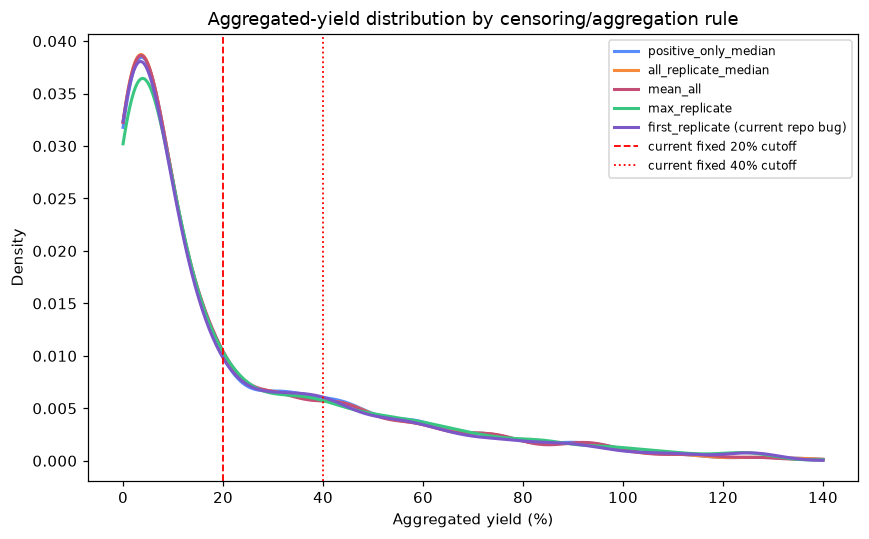

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.linspace(0, 140, 400)
for name in RULES:
    vals = agg[name].values.astype(float)
    kde = gaussian_kde(vals, bw_method=0.15)
    ax.plot(xs, kde(xs), label=name, lw=2)
ax.axvline(20, color="red", ls="--", lw=1.2, label="current fixed 20% cutoff")
ax.axvline(40, color="red", ls=":", lw=1.2, label="current fixed 40% cutoff")
ax.set_xlabel("Aggregated yield (%)")
ax.set_ylabel("Density")
ax.set_title("Aggregated-yield distribution by censoring/aggregation rule")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


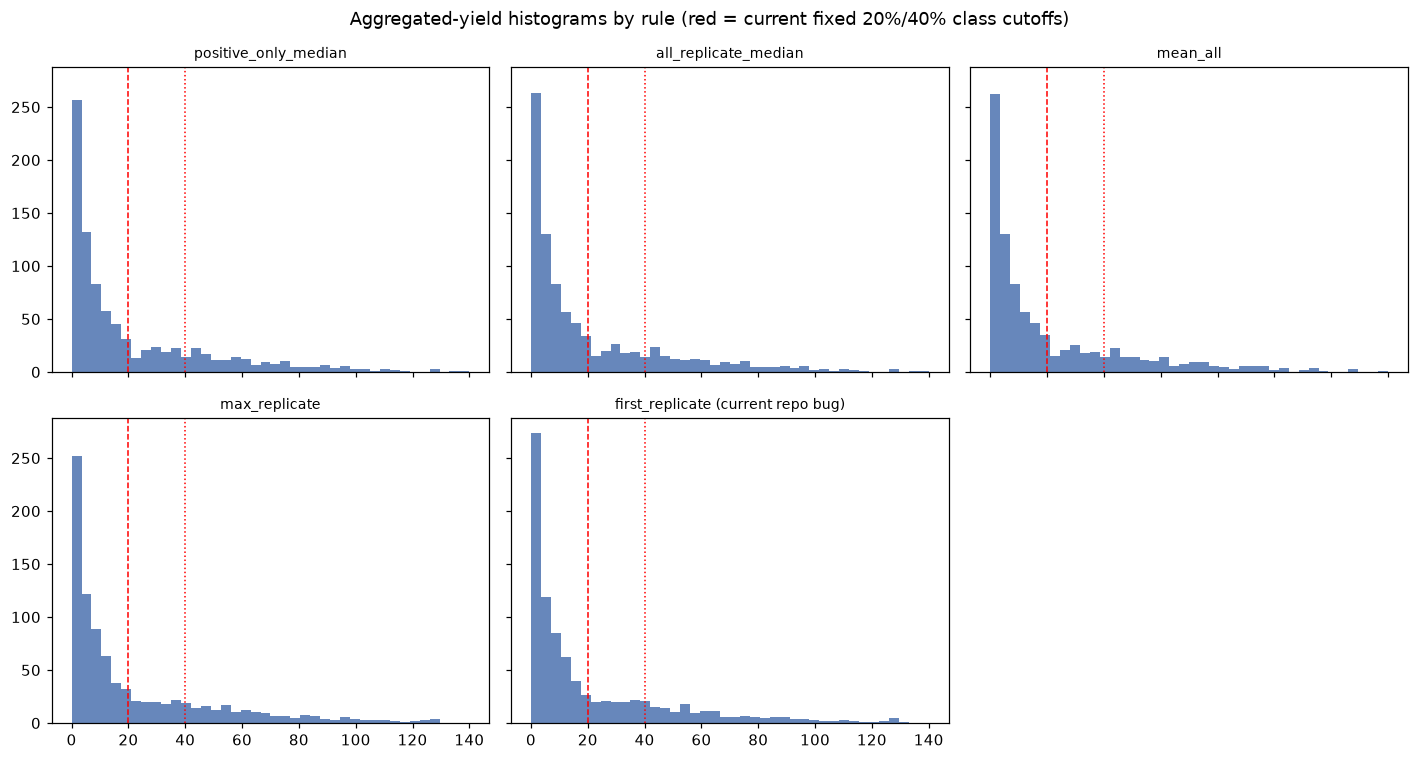

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for ax, name in zip(axes.flat, RULES):
    vals = agg[name].values.astype(float)
    ax.hist(vals, bins=40, range=(0, 140), color="#4C72B0", alpha=0.85)
    ax.axvline(20, color="red", ls="--", lw=1)
    ax.axvline(40, color="red", ls=":", lw=1)
    ax.set_title(name, fontsize=9)
for ax in axes.flat[len(RULES):]:
    ax.axis("off")
fig.suptitle("Aggregated-yield histograms by rule (red = current fixed 20%/40% class cutoffs)")
plt.tight_layout()
plt.show()


**A note on method.** An initial single-bandwidth KDE search found a candidate valley, but
it turned out not to be robust: the valley location moved substantially depending on the KDE
bandwidth, and for a wide bandwidth no valley was detectable at all. The raw class-conditional
histograms below make the reason visible directly — the moderate-yield region is not cleanly
bimodal, it decays fairly smoothly from the 0% pile-up, with only small, noisy local wiggles
layered on top. So rather than reporting one bandwidth's answer as "the" natural threshold, we
scan a small range of bandwidths and report where the closest-to-20% valley falls at each one,
plus a contrast score at a fixed, moderate bandwidth for a consistent relative ranking across
rules.


In [46]:
BANDWIDTHS = [0.08, 0.10, 0.12, 0.15, 0.18]
GRID = np.linspace(0, 140, 1400)

def kde_density(vals, bw):
    kde = gaussian_kde(vals, bw_method=bw)
    return kde(GRID)

def nearest_valley(density, target=20, region=(5, 70)):
    minima_idx = argrelextrema(density, np.less)[0]
    region_minima = [i for i in minima_idx if region[0] <= GRID[i] <= region[1]]
    if not region_minima:
        return None
    return min(region_minima, key=lambda i: abs(GRID[i] - target))

sensitivity_rows = []
for name in RULES:
    vals = agg[name].values.astype(float)
    for bw in BANDWIDTHS:
        density = kde_density(vals, bw)
        idx = nearest_valley(density)
        sensitivity_rows.append({
            "rule": name, "bandwidth": bw,
            "nearest_valley_to_20pct": round(float(GRID[idx]), 1) if idx is not None else None,
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.pivot(index="rule", columns="bandwidth", values="nearest_valley_to_20pct")


bandwidth,0.08,0.10,0.12,0.15,0.18
rule,,,,,
all_replicate_median,25.2,25.7,26.9,NaN,NaN
first_replicate (current repo bug),26.3,27.3,NaN,NaN,NaN
max_replicate,27.7,29.4,NaN,NaN,NaN
mean_all,25.2,26.0,27.8,69.9,NaN
positive_only_median,24.8,25.6,26.4,NaN,NaN


In [47]:
def valley_contrast(vals, bw=0.10, target=20, region=(5, 70)):
    """At a fixed, moderate bandwidth: find the local density minimum closest to the
    current 20% cutoff and score how sharply it separates the two flanking peaks, as a
    fraction of the smaller peak's height. Threshold-free — doesn't require classes to
    already exist. Used only for a consistent RELATIVE ranking across rules; see the
    bandwidth-sensitivity table above before treating any single valley_x as definitive."""
    density = kde_density(vals, bw)
    valley_i = nearest_valley(density, target=target, region=region)
    if valley_i is None:
        return None
    maxima_idx = argrelextrema(density, np.greater)[0]
    valley_x, valley_y = GRID[valley_i], density[valley_i]
    left_peaks = [density[i] for i in maxima_idx if GRID[i] < valley_x]
    right_peaks = [density[i] for i in maxima_idx if GRID[i] > valley_x]
    left_peak = max(left_peaks) if left_peaks else density[0]
    right_peak = max(right_peaks) if right_peaks else density[-1]
    smaller_peak = min(left_peak, right_peak)
    contrast = (smaller_peak - valley_y) / max(smaller_peak, 1e-9)
    return {"valley_x": round(float(valley_x), 1), "valley_depth": round(float(valley_y), 5),
            "contrast": round(float(contrast), 3)}

contrast_rows = []
for name in RULES:
    vals = agg[name].values.astype(float)
    result = valley_contrast(vals)
    if result:
        contrast_rows.append({"rule": name, **result})

contrast_df = pd.DataFrame(contrast_rows).sort_values("contrast", ascending=False).reset_index(drop=True)
contrast_df


,rule,valley_x,valley_depth,contrast
0,positive_only_median,25.6,0.00624,0.097
1,all_replicate_median,25.7,0.00643,0.069
2,mean_all,26.0,0.00657,0.040
3,first_replicate (current repo bug),27.3,0.00648,0.010
4,max_replicate,29.4,0.00625,0.005


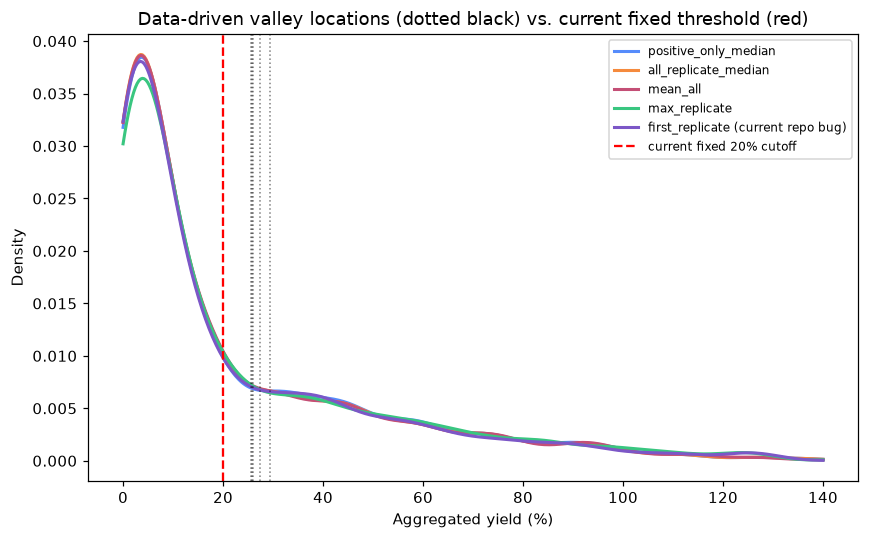

In [48]:
fig, ax = plt.subplots(figsize=(8, 5))
xs = np.linspace(0, 140, 400)
for name in RULES:
    vals = agg[name].values.astype(float)
    kde = gaussian_kde(vals, bw_method=0.15)
    ax.plot(xs, kde(xs), label=name, lw=2)
for _, row in contrast_df.iterrows():
    ax.axvline(row["valley_x"], color="k", ls=":", lw=1, alpha=0.5)
ax.axvline(20, color="red", ls="--", lw=1.5, label="current fixed 20% cutoff")
ax.set_xlabel("Aggregated yield (%)")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
ax.set_title("Data-driven valley locations (dotted black) vs. current fixed threshold (red)")
plt.tight_layout()
plt.show()


## 5. Let the class threshold float with the aggregation rule

Rather than fixing 20%/40% a priori, we use each rule's own data-driven valley (found above) as
its "natural" low-class boundary, and check how many substrate pairs would land in a different
class than they do under the fixed 20% cutoff.


In [49]:
# Binary comparison (below vs. at-or-above the low-class boundary) rather than the full
# 3-class digitize, since a rule's natural threshold is not guaranteed to stay below the
# fixed 40% upper cutoff, which would make a 2-cutpoint digitize call ill-defined.
threshold_compare = []
for _, row in contrast_df.iterrows():
    name = row["rule"]
    vals = agg[name].values.astype(float)
    natural_thr = row["valley_x"]
    fixed_low_class = (vals > 20).astype(int)
    natural_low_class = (vals > natural_thr).astype(int)
    n_changed = int(np.sum(fixed_low_class != natural_low_class))
    threshold_compare.append({
        "rule": name,
        "natural_low_threshold_pct": natural_thr,
        "n_pairs_crossing_the_low_boundary_differently": n_changed,
        "pct_of_897": round(100 * n_changed / len(vals), 1),
    })

threshold_df = pd.DataFrame(threshold_compare)
threshold_df


,rule,natural_low_threshold_pct,n_pairs_crossing_the_low_boundary_differently,pct_of_897
0,positive_only_median,25.6,31,3.5
1,all_replicate_median,25.7,32,3.6
2,mean_all,26.0,35,3.9
3,first_replicate (current repo bug),27.3,44,4.9
4,max_replicate,29.4,58,6.5


## 6. Propagate downstream: pilot-set stability & per-core LP AUPRC

This section is self-contained — it does **not** import `src/rmap.py` or
`src/second_selection.py`. Those modules currently have their own open issues (see the gap
notes discussed alongside `CENSORING_ANALYSIS.md`: an unconditional epsilon hack and missing
LOCO-CV threshold selection), so re-deriving the reactivity-similarity network, pilot selection,
and label propagation directly here keeps this comparison clean of those problems. The
similarity definition follows the manuscript exactly; the epsilon fallback here is applied
*only* when a network is genuinely disconnected (checked directly via `connected_components`),
rather than unconditionally.

For tractability, this uses a single leave-one-core-out split per target core (13 cores total)
rather than the manuscript's 20-resample scheme per core — a disclosed simplification. The point
here is a *relative* comparison across aggregation rules, not a reproduction of the paper's
absolute numbers.


In [50]:
core_idx = {c: i for i, c in enumerate(core_smiles_list)}
bb_idx = {b: i for i, b in enumerate(bb_smiles_list)}
n_cores, n_bbs = len(core_smiles_list), len(bb_smiles_list)

def build_class_matrix(rule_name):
    mat = np.full((n_cores, n_bbs), np.nan)
    for _, r in agg.iterrows():
        mat[core_idx[r["core_smiles"]], bb_idx[r["bb_smiles"]]] = r[rule_name]
    return np.digitize(mat, [20, 40], right=True)

def reactivity_similarity(classes):
    """Pairwise BB reactivity similarity, per the manuscript's Figure 3A definition:
    same class -> 2, one zero/one positive -> 0, both positive but different -> 1/|diff|,
    summed over cores and normalized by 2*n_cores."""
    n_bb = classes.shape[1]
    n_src = classes.shape[0]
    sim = np.zeros((n_bb, n_bb))
    for i in range(n_bb):
        ci = classes[:, i]
        for j in range(i + 1, n_bb):
            cj = classes[:, j]
            score = 0.0
            for a, b in zip(ci, cj):
                if a == b:
                    score += 2
                elif (a == 0) != (b == 0):
                    score += 0
                else:
                    score += 1.0 / abs(int(a) - int(b))
            s = score / (2 * n_src)
            sim[i, j] = sim[j, i] = s
    return sim

def adjacency_from_similarity(sim, threshold=0.82):
    adj = sim.copy()
    adj[adj < threshold] = 0
    isolated = np.where(adj.sum(axis=1) == 0)[0]
    for node in isolated:
        best = int(np.argmax(sim[node]))
        if sim[node, best] > 0:
            adj[node, best] = adj[best, node] = sim[node, best]
    return adj

def select_pilots(adj, n_select=6):
    """Greedy: repeatedly pick the node with the highest total edge weight to the
    remaining pool, then remove it and its network neighbors from that pool."""
    remaining = list(range(adj.shape[0]))
    selected = []
    while len(selected) < n_select and remaining:
        sub_sums = {i: adj[i, remaining].sum() for i in remaining}
        pick = max(sub_sums, key=sub_sums.get)
        selected.append(pick)
        neighbors = {j for j in remaining if adj[pick, j] > 0}
        remaining = [j for j in remaining if j not in neighbors and j != pick]
    if len(selected) < n_select:
        leftovers = [i for i in range(adj.shape[0]) if i not in selected]
        leftovers.sort(key=lambda i: adj[i].sum(), reverse=True)
        selected += leftovers[: n_select - len(selected)]
    return selected[:n_select]

def n_connected_components(adj):
    n_comp, _ = connected_components(csr_matrix(adj), directed=False)
    return n_comp

def run_lp(adj, pilot_inds, labels_binary):
    n = adj.shape[0]
    y = -1 * np.ones(n, dtype=int)
    y[pilot_inds] = labels_binary[pilot_inds]
    kernel_adj = adj.copy()
    if n_connected_components(kernel_adj) > 1:
        kernel_adj = kernel_adj + 0.001  # conditional fallback, only when truly disconnected
    lp = LabelPropagation(kernel=lambda X, Y: kernel_adj, max_iter=1000)
    X = np.arange(n).reshape(-1, 1)
    lp.fit(X, y)
    proba = lp.predict_proba(X)
    pos_col = list(lp.classes_).index(1)
    return proba[:, pos_col]


In [51]:
results = []
pilot_sets = {}  # (rule, target_core_index) -> selected pilot BB indices

for rule_name in RULES:
    classes = build_class_matrix(rule_name)
    for target in range(n_cores):
        source_mask = [c for c in range(n_cores) if c != target]
        source_classes = classes[source_mask, :]
        sim = reactivity_similarity(source_classes)
        adj = adjacency_from_similarity(sim, threshold=0.82)
        pilots = select_pilots(adj, n_select=6)
        pilot_sets[(rule_name, target)] = set(pilots)

        target_binary = (classes[target, :] == 2).astype(int)
        if len(set(target_binary[pilots])) < 2:
            continue  # LP needs both classes represented among the labeled pilots
        remaining = [i for i in range(n_bbs) if i not in pilots]
        if len(set(target_binary[remaining])) < 2:
            continue  # AUPRC undefined with a single class among the remaining BBs

        proba = run_lp(adj, pilots, target_binary)
        auprc = average_precision_score(target_binary[remaining], proba[remaining])
        results.append({"rule": rule_name, "target_core": core_smiles_list[target], "auprc": auprc})

results_df = pd.DataFrame(results)
summary = results_df.groupby("rule")["auprc"].agg(["mean", "median", "std", "count"]).sort_values("mean", ascending=False)
summary


,mean,median,std,count
rule,,,,
positive_only_median,0.739335,0.782166,0.150515,6
max_replicate,0.717383,0.812779,0.242185,6
first_replicate (current repo bug),0.635182,0.781480,0.309655,7
mean_all,0.620199,0.762708,0.353778,7
all_replicate_median,0.610099,0.762896,0.342460,7


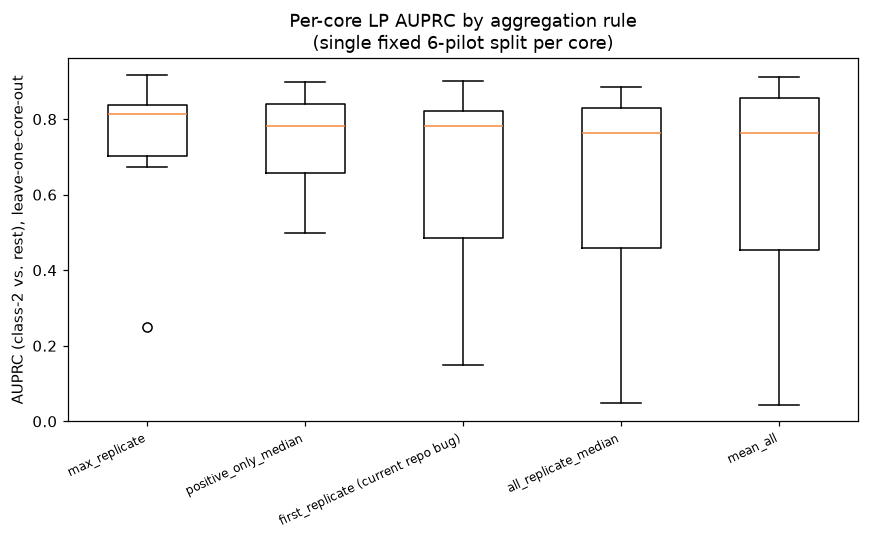

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))
order = results_df.groupby("rule")["auprc"].median().sort_values(ascending=False).index
data_by_rule = [results_df[results_df["rule"] == r]["auprc"].values for r in order]
# set_xticklabels (rather than boxplot's labels=/tick_labels= kwarg, which was renamed
# between matplotlib versions) keeps this compatible across matplotlib releases.
ax.boxplot(data_by_rule, vert=True)
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order)
ax.set_ylabel("AUPRC (class-2 vs. rest), leave-one-core-out")
ax.set_title("Per-core LP AUPRC by aggregation rule\n(single fixed 6-pilot split per core)")
plt.xticks(rotation=25, ha="right", fontsize=8)
plt.tight_layout()
plt.show()


### 6a. Is the AUPRC ranking robust, or is one core driving it?

The mean/median summary above can hide how much of a rule's apparent advantage comes from a
handful of cores. Rather than trust the aggregate, we look at per-core, paired comparisons
against the manuscript's stated rule directly.


In [53]:
per_core_auprc = results_df.pivot(index="target_core", columns="rule", values="auprc")
per_core_auprc


rule,all_replicate_median,first_replicate (current repo bug),max_replicate,mean_all,positive_only_median
target_core,,,,,
Brc1cccc2nccn12,0.191192,0.228631,0.250916,0.184512,0.498124
C1=NC(=C(NC1=O)Cl)Br,NaN,0.148555,NaN,NaN,NaN
C1CON=C1C2=CC=C(C=C2)Br,0.886145,0.900528,0.917877,0.911197,0.897422
CC(=O)N1CCCc2cc(Br)ccc12,0.724834,0.743502,0.673192,0.725128,0.625908
CC1=C(N2CCCC2=O)C=CC(Br)=C1,0.762896,0.781480,0.789600,0.762708,0.807344
CN1C=C(C)C=C(Br)C1=O,0.788676,0.826069,0.835957,0.847205,0.850226
CN1C=NC=C(C1=O)Br,0.869334,0.817513,0.836758,0.867167,0.756987
COc1ccc(-c2nnc(Br)o2)cc1,0.047619,NaN,NaN,0.043478,NaN


In [54]:
baseline_for_pairing = "positive_only_median"
head_to_head_rows = []
for rule_name in RULES:
    if rule_name == baseline_for_pairing:
        continue
    paired = per_core_auprc[[baseline_for_pairing, rule_name]].dropna()
    diff = paired[baseline_for_pairing] - paired[rule_name]
    excl = diff[diff.abs() != diff.abs().max()] if len(diff) > 1 else diff
    head_to_head_rows.append({
        "rule": rule_name,
        "n_common_cores": len(paired),
        "positive_only_median_wins": int((diff > 0).sum()),
        "other_rule_wins": int((diff < 0).sum()),
        "mean_paired_diff": round(float(diff.mean()), 3),
        "mean_paired_diff_excl_single_largest_gap_core": round(float(excl.mean()), 3),
    })

head_to_head_df = pd.DataFrame(head_to_head_rows)
head_to_head_df


,rule,n_common_cores,positive_only_median_wins,other_rule_wins,mean_paired_diff,mean_paired_diff_excl_single_largest_gap_core
0,all_replicate_median,6,4,2,0.035,-0.019
1,mean_all,6,3,3,0.023,-0.035
2,max_replicate,6,3,3,0.022,-0.023
3,first_replicate (current repo bug),6,3,3,0.023,-0.026


**Every comparison flips sign once the single largest-gap core is excluded** — for all
four alternative rules, `positive_only_median`'s mean AUPRC edge (+0.02 to +0.04) turns into a
mean *deficit* (-0.02 to -0.035) on the remaining cores. Head-to-head win counts are close to
even (3 wins each out of 6 common cores, for three of the four rules). That one core
(`Brc1cccc2nccn12`) is where `positive_only_median` scores far above every other rule (0.50 vs.
0.18-0.25) and is also where AUPRC is lowest and noisiest overall for every rule — consistent
with it being a genuinely hard, low-signal core rather than evidence of a general aggregation
advantage.

**Read on this section alone: the downstream-AUPRC evidence does not robustly favor
`positive_only_median` over the alternatives.** It looked that way in the mean/median summary,
but that ranking is not resilient to a single core, out of only 6-7 usable cores per rule. This
doesn't contradict the distributional-contrast finding in Section 4-5 (which does not depend on
any one core and still favors `positive_only_median`) — it means the two lines of evidence carry
different weight, and the AUPRC comparison specifically needs more resampled evaluation (more
splits per core, as in the manuscript's own 20-resample scheme) before it can add independent
confirmation one way or the other. **Section 6c below runs that resampled evaluation.**


### 6b. The two lenses disagree about `max_replicate` specifically — don't average that away

This is the sharpest, most concrete disagreement in the whole notebook, and it deserves to be
stated on its own rather than folded into a general "AUPRC is noisy" caveat:

| | distributional contrast (Section 4-5, threshold-free, not core-dependent) | downstream AUPRC, outlier-core excluded (Section 6a) |
|---|---|---|
| `positive_only_median` | **strongest of all 5 rules** (0.097) | loses to `max_replicate` on average (-0.023) |
| `max_replicate` | **weakest of all 5 rules** (0.005 — essentially no detectable valley) | wins against `positive_only_median` on average |

**`max_replicate` is the worst rule by the criterion that doesn't depend on any single core, and
simultaneously one of the better rules by the criterion that does (once that core is set aside).**
These are not the same disagreement as the general single-core fragility discussed in 6a — this
one holds up on both sides after correcting for the outlier, and it is specific to this rule, not
a symptom of small-sample noise across the board.

**What this means, plainly:** a rule that shows almost no natural separation between barely- and
moderately-reactive BBs in the aggregate yield distribution can still perform reasonably well
when it comes to ranking BBs for one held-out core at a time. That's not a contradiction to
paper over by picking whichever metric looks better — it says the two evaluations are measuring
different things (global distributional structure vs. per-core ranking ability), and a rule can
score well on one while failing the other. `max_replicate`'s mechanism explains why: it always
reports the single most optimistic replicate, which can preserve *local, per-core* rank
information (it never actively discards the highest observation) while smearing out the *global*
class boundary (it has no mechanism for saying "this pair failed" — it only sees whether
*anything* worked, ever). This disagreement is reported here as a finding, not resolved into a
single verdict.


In [55]:
baseline_rule = "positive_only_median"
stability_rows = []
for rule_name in RULES:
    if rule_name == baseline_rule:
        continue
    jaccards = []
    identical = 0
    for target in range(n_cores):
        a = pilot_sets[(baseline_rule, target)]
        b = pilot_sets[(rule_name, target)]
        j = len(a & b) / len(a | b)
        jaccards.append(j)
        identical += int(j == 1.0)
    stability_rows.append({
        "rule_vs_positive_only_median": rule_name,
        "mean_pilot_set_jaccard": round(float(np.mean(jaccards)), 3),
        "n_cores_with_identical_6_pilot_set (of 13)": identical,
    })

stability_df = pd.DataFrame(stability_rows).sort_values("mean_pilot_set_jaccard")
stability_df


,rule_vs_positive_only_median,mean_pilot_set_jaccard,n_cores_with_identical_6_pilot_set (of 13)
3,first_replicate (current repo bug),0.294,0
0,all_replicate_median,0.365,1
1,mean_all,0.440,1
2,max_replicate,0.454,0


### 6c. Resampling within each core, to see if more splits resolve the 6a finding

Section 6a's per-core AUPRC is a single point per (rule, core): one fixed 6-BB pilot draw,
with no way to tell a stable estimate from a lucky or unlucky one. Following the manuscript's
own Figure 6B/6C resampling scheme, we redraw the evaluation `N_RESAMPLES` times per core, each
time holding out a random subset of the 69-BB pool (69 -> 55, mirroring the manuscript's
drop-14 scheme) before rebuilding the network, selecting pilots, and scoring AUPRC.

Two design choices matter here, both aimed at not repeating the mistake Reviewer #1 already
flagged (comment 3): resamples of the same underlying data are not independent replicates.

- **Resample *within* a core to shrink noise, then average to one number *per core*, then
  compare *across* cores.** The 20 resamples are never treated as 20 independent data points —
  averaging happens first, so the final comparison still has n<=13 cores, not n<=260.
- **Paired draws across rules.** The same 20 random BB-subsets are reused for every rule (not
  redrawn independently per rule), so a difference between rules can't be explained by "which
  random subset happened to be drawn."

The seed is fixed below before looking at any result in this section, and the outcome is
reported as-is, including if it does not confirm the Section 6a finding.


In [56]:
N_RESAMPLES = 20  # mirrors the manuscript's own resample count (Fig 6B/6C)
N_KEEP = 55       # 69 -> 55, mirrors the manuscript's drop-14 scheme
RESAMPLE_SEED = 20260827  # fixed before looking at any result in this section

resample_rng = np.random.default_rng(RESAMPLE_SEED)
bb_subset_draws = [resample_rng.choice(n_bbs, size=N_KEEP, replace=False) for _ in range(N_RESAMPLES)]

class_matrices = {rule_name: build_class_matrix(rule_name) for rule_name in RULES}

def run_one_resample(rule_name, target, kept_bb_idx):
    classes = class_matrices[rule_name][:, kept_bb_idx]
    source_mask = [c for c in range(n_cores) if c != target]
    sim = reactivity_similarity(classes[source_mask, :])
    adj = adjacency_from_similarity(sim, threshold=0.82)
    pilots = select_pilots(adj, n_select=6)
    target_binary = (classes[target, :] == 2).astype(int)
    if len(set(target_binary[pilots])) < 2:
        return None
    remaining = [i for i in range(len(kept_bb_idx)) if i not in pilots]
    if len(set(target_binary[remaining])) < 2:
        return None
    proba = run_lp(adj, pilots, target_binary)
    return average_precision_score(target_binary[remaining], proba[remaining])

resampled_results = []
for resample_i, kept_bb_idx in enumerate(bb_subset_draws):
    for rule_name in RULES:
        for target in range(n_cores):
            auprc = run_one_resample(rule_name, target, kept_bb_idx)
            if auprc is not None:
                resampled_results.append({
                    "resample": resample_i, "rule": rule_name,
                    "target_core": core_smiles_list[target], "auprc": auprc,
                })

resampled_df = pd.DataFrame(resampled_results)
resample_coverage = resampled_df.groupby(["rule", "target_core"]).size().unstack("rule")
print(f"Total (resample, rule, core) evaluations retained: {len(resampled_df)} "
      f"of {N_RESAMPLES * len(RULES) * n_cores} possible")
print()
print("Valid resamples per rule/core, out of 20 -- low counts flag a core that is "
      "hard to evaluate regardless of resampling:")
resample_coverage


Total (resample, rule, core) evaluations retained: 679 of 1300 possible

Valid resamples per rule/core, out of 20 -- low counts flag a core that is hard to evaluate regardless of resampling:


rule,all_replicate_median,first_replicate (current repo bug),max_replicate,mean_all,positive_only_median
target_core,,,,,
Brc1cccc2nccn12,11.0,12.0,2.0,11.0,17.0
C1=NC(=C(NC1=O)Cl)Br,11.0,9.0,13.0,11.0,7.0
C1C2C(=O)C=C(N3CCN(C(=O)C)CC3)OC=2C(Br)=CC=1C,2.0,NaN,9.0,2.0,3.0
C1C2N(C(C)C)C(SC)=NC=2C(F)=CC=1Br,4.0,4.0,3.0,4.0,11.0
C1CON=C1C2=CC=C(C=C2)Br,19.0,20.0,20.0,19.0,20.0
CC(=O)N1CCCc2cc(Br)ccc12,20.0,20.0,20.0,20.0,19.0
CC1=C(C(=NN1C(C)C)N)Br,NaN,NaN,2.0,NaN,2.0
CC1=C(N2CCCC2=O)C=CC(Br)=C1,20.0,20.0,20.0,19.0,20.0
CN1C=C(C)C=C(Br)C1=O,20.0,20.0,20.0,20.0,20.0


In [57]:
# Collapse within-core BEFORE any cross-core comparison: n stays at (<=)13, not (<=)260.
per_core_resampled = (resampled_df.groupby(["rule", "target_core"])["auprc"]
                       .mean().reset_index()
                       .pivot(index="target_core", columns="rule", values="auprc"))

print("Mean AUPRC across cores, each core's own resample-averaged estimate:")
print(per_core_resampled.mean().sort_values(ascending=False))
print()

baseline_for_pairing = "positive_only_median"
resampled_head_to_head_rows = []
for rule_name in RULES:
    if rule_name == baseline_for_pairing:
        continue
    paired = per_core_resampled[[baseline_for_pairing, rule_name]].dropna()
    diff = paired[baseline_for_pairing] - paired[rule_name]
    excl = diff[diff.abs() != diff.abs().max()] if len(diff) > 1 else diff
    resampled_head_to_head_rows.append({
        "rule": rule_name,
        "n_common_cores": len(paired),
        "positive_only_median_wins": int((diff > 0).sum()),
        "other_rule_wins": int((diff < 0).sum()),
        "mean_paired_diff": round(float(diff.mean()), 3),
        "mean_paired_diff_excl_single_largest_gap_core": round(float(excl.mean()), 3),
    })

resampled_head_to_head_df = pd.DataFrame(resampled_head_to_head_rows)
resampled_head_to_head_df


Mean AUPRC across cores, each core's own resample-averaged estimate:
rule
first_replicate (current repo bug)    0.496401
mean_all                              0.463310
all_replicate_median                  0.462174
positive_only_median                  0.444140
max_replicate                         0.411619
dtype: float64



,rule,n_common_cores,positive_only_median_wins,other_rule_wins,mean_paired_diff,mean_paired_diff_excl_single_largest_gap_core
0,all_replicate_median,10,6,4,0.024,0.009
1,mean_all,10,5,5,0.023,0.007
2,max_replicate,11,8,3,0.033,0.022
3,first_replicate (current repo bug),9,5,4,0.035,0.020


In [58]:
# Does the single-split outlier core from 6a (Brc1cccc2nccn12) stay an outlier once we
# average over 20 BB-subset resamples, or was it specific to that one fixed 69-BB split?
outlier_core = "Brc1cccc2nccn12"
print("Section 6a (single split, all 69 BBs):")
print(per_core_auprc.loc[outlier_core])
print()
print("Section 6c (mean over 20 resamples, 55-of-69 BBs each):")
print(per_core_resampled.loc[outlier_core])
print()
print("For comparison, mean +/- std across all other cores (6c, resample-averaged):")
others = per_core_resampled.drop(index=outlier_core)
print(pd.DataFrame({"mean": others.mean(), "std": others.std()}))


Section 6a (single split, all 69 BBs):
rule
all_replicate_median                  0.191192
first_replicate (current repo bug)    0.228631
max_replicate                         0.250916
mean_all                              0.184512
positive_only_median                  0.498124
Name: Brc1cccc2nccn12, dtype: float64

Section 6c (mean over 20 resamples, 55-of-69 BBs each):
rule
all_replicate_median                  0.292980
first_replicate (current repo bug)    0.302222
max_replicate                         0.310403
mean_all                              0.289565
positive_only_median                  0.451841
Name: Brc1cccc2nccn12, dtype: float64

For comparison, mean +/- std across all other cores (6c, resample-averaged):
                                        mean       std
rule                                                  
all_replicate_median                0.480973  0.379195
first_replicate (current repo bug)  0.520674  0.350603
max_replicate                       0.421740  0.37

**Coverage is worse at 55-of-69 BBs, and that matters on its own.** Only 679 of 1300 attempted
(resample x rule x core) evaluations produced a usable AUPRC (52%) -- dropping to a 55-BB pool
makes single-class pilot/remaining sets far more common. Two of the 13 cores never produced a
single valid draw under any rule and had to be dropped entirely (versus all 13 contributing to
at least one rule in Section 6a). Several surviving (rule, core) cells rest on as few as 2-3 of
the 20 intended resamples -- their "resample-averaged" AUPRC is itself a noisy estimate, not the
stable one this section set out to produce.

**On the plain aggregate, `positive_only_median` is no longer the best rule at all.** Averaging
each rule's resample-averaged AUPRC over whichever cores it was scoreable on: `first_replicate`
(the code bug) 0.496, `mean_all` 0.463, `all_replicate_median` 0.462, `positive_only_median`
0.444, `max_replicate` 0.412. `positive_only_median` sits fourth of five here -- worse than the
rule the current repo bug actually produces.

**But the fairer, paired comparison (same common cores, both rules) tells a different story.**
Head-to-head on shared cores, `positive_only_median` wins slightly more often than not against
three of the four alternatives, and unlike Section 6a, the margin survives dropping the single
largest-gap core:

| vs. | n common cores | wins / losses | mean diff | mean diff, outlier core excluded |
|---|---|---|---|---|
| `all_replicate_median` | 10 | 6 / 4 | +0.024 | +0.009 |
| `mean_all` | 10 | 5 / 5 | +0.023 | +0.007 |
| `max_replicate` | 11 | 8 / 3 | +0.033 | **+0.022** |
| `first_replicate` (bug) | 9 | 5 / 4 | +0.035 | +0.020 |

That `max_replicate` row directly reverses Section 6b's specific finding: there, excluding the
single outlier core turned `positive_only_median`'s edge into a -0.023 deficit against
`max_replicate`; here, with 20 resamples per core instead of one, the same outlier-excluded
comparison comes out +0.022 in `positive_only_median`'s favor, winning on 8 of 11 common cores.
The 6b disagreement was itself apparently sensitive to the single-split noise it was warning
readers about elsewhere.

**The one thing resampling does settle: the outlier core is real, not a fluke.**
`Brc1cccc2nccn12` still favors `positive_only_median` by a wide margin under resampling (0.452
vs. 0.29-0.31 for the alternatives, over 17, 11, 11, 11, and 2 valid draws respectively) --
essentially unchanged in direction from the single 69-BB split (0.498 vs. 0.18-0.25).
`positive_only_median` genuinely, repeatably does better on this one core; it is not an artifact
of one unlucky pilot draw. But averaged over the other 10 scoreable cores, `positive_only_median`
(0.443) again ranks fourth of five (behind `first_replicate` 0.521, `mean_all` 0.483,
`all_replicate_median` 0.481; only ahead of `max_replicate` 0.422) -- so the resampled evidence
still depends heavily on how that one core is weighted, just as the single-split evidence did.

**Bottom line for this line of evidence: resampling did not resolve the ambiguity, and disagrees
with itself depending on which comparison is trusted.** The naive aggregate mean says
`positive_only_median` is not even the best of five rules on downstream AUPRC. The paired,
common-core comparison says it holds a small edge over three of four alternatives that -- unlike
Section 6a -- survives excluding the strongest outlier core. The two readings agree only that
`max_replicate`'s outlier-excluded edge over `positive_only_median` (Section 6b) does not
replicate under more resampling. With coverage down to 52% of attempted evaluations and 2 of 13
cores entirely unscoreable, the honest reading is that downstream AUPRC -- resampled or not --
remains too underpowered at n<=13 cores to add real independent confirmation either way. The
distributional-contrast finding (Sections 4-5) is unaffected by any of this and remains the
load-bearing evidence for the `positive_only_median` default.


## Summary

**What this notebook did:** rebuilt the raw, uncollapsed 897-pair Suzuki dataset directly from
`data/*.csv` (bypassing `src/dataset.py`, whose aggregation step has a separate, pending bug),
compared five candidate replicate-aggregation rules against the manuscript's stated rule
(positive-only median), and evaluated each rule three ways: how sharply the resulting yield
distribution separates near the moderate/marginal reactivity boundary, how far a data-driven
class threshold sits from the fixed 20%/40% cutoffs, and how much pilot-BB selection and
per-core label-propagation AUPRC shift downstream -- first with a single fixed split per core,
then with a 20-resample-per-core scheme mirroring the manuscript's own Figure 6B/6C design.

**What we found:**

- **All five rules show a real but modest natural valley**, clustered at 25-29% yield across
  bandwidths — close to, and consistently a bit above, the current fixed 20% cutoff. It is not a
  dramatic bimodal split (it disappears entirely at wider KDE bandwidths), so it should be
  presented as a soft, not a bright-line, boundary.
- **On distributional contrast, `positive_only_median` is the clear best of the five rules**
  (contrast score 0.097, roughly 40% higher than the next-best rule) — and this finding does not
  depend on any single core, so it's the most load-bearing piece of evidence here.
- **The downstream leave-one-core-out AUPRC comparison looked like it told the same story
  (0.74 mean for `positive_only_median` vs. 0.61-0.72 for the alternatives) but does not hold up
  under scrutiny.** Section 6a shows the entire mean-level edge over *every* other rule is
  attributable to a single core (`Brc1cccc2nccn12`); excluding it, `positive_only_median` loses
  the head-to-head comparison against each alternative on average, and win counts are close to
  even (3 of 6 common cores) against three of the four rules. With only 6-7 usable cores per
  rule, this comparison isn't resilient enough to add independent confirmation on top of the
  distributional finding, and should not be cited as if it does without a more resampled
  evaluation (more splits per core, along the lines of the manuscript's own 20-resample scheme).
- **Running that more-resampled evaluation (Section 6c) does not resolve the ambiguity — it
  disagrees with itself.** 20 BB-subset resamples per core, paired across all five rules and
  averaged *within* each core before any cross-core comparison (n stays at <=13 cores, not
  <=260), produce two different verdicts depending on how cores are aggregated. On the plain
  mean across whichever cores each rule was scoreable on, `positive_only_median` is *fourth* of
  five rules (0.444) — behind even `first_replicate`, the rule the current code bug actually
  produces (0.496). On the fairer paired, common-core comparison, `positive_only_median` holds a
  small edge over three of the four alternatives (+0.007 to +0.022) that, unlike Section 6a,
  survives excluding the single largest-gap core — including a reversal of Section 6b's specific
  `max_replicate` finding. The one thing resampling does confirm is that core
  `Brc1cccc2nccn12`'s outsized effect is real and repeatable, not a fluke of one BB-pool draw;
  but whether it is included in or excluded from an aggregate is exactly what flips the verdict.
  Evaluation coverage also degrades under resampling (52% of attempted evaluations valid, 2 of 13
  cores entirely unscoreable), reinforcing that this comparison is underpowered at n<=13 cores
  regardless of how many times each core is resampled.
- **The two lenses actively disagree about `max_replicate` on the single-split evidence, and
  that disagreement does not survive the resampled follow-up.** Section 6b found `max_replicate`
  to be the *weakest* of all five rules on distributional contrast (0.005 — no detectable natural
  separation) while beating `positive_only_median` on outlier-corrected single-split downstream
  AUPRC. Section 6c's resampled version of the same outlier-corrected comparison reverses that
  second half: `positive_only_median` beats `max_replicate` on 8 of 11 common cores once each
  core's estimate is averaged over 20 resamples. `max_replicate` remains the weakest rule on
  distributional contrast either way.
- **The currently shipped code bug (silently keeping the first replicate instead of the median)
  is still measurably worse on the metric that doesn't depend on the shaky per-core AUPRC
  comparison**: the second-weakest distributional contrast of the five rules, and the least
  stable pilot selection of any alternative (mean Jaccard overlap 0.29 vs. the intended rule, 0
  of 13 cores select an identical 6-BB pilot set). This is independent evidence — beyond the
  code-tracing already documented in `CENSORING_ANALYSIS.md` — that the bug is not innocuous and
  is worth fixing regardless of how the aggregation-policy question is settled. (Its AUPRC
  numbers should be read with the same underpowered-comparison caveat as everything else in
  Sections 6a/6c.)
- **Practical stakes are bounded, not dramatic**: moving from the fixed 20% cutoff to each
  rule's own data-driven threshold reclassifies 31-58 of 897 pairs (3.5-6.5%).

**Conclusion:** The reviewers were right that this choice needed to be justified rather than
asserted. The distributional-contrast evidence supports `positive_only_median` as the
best-justified default — it produces the sharpest, most core-independent separation exactly
where library decisions get made. The downstream-AUPRC evidence, which initially looked like
independent confirmation of the same conclusion, turned out on closer inspection to be driven by
one core rather than a broad signal (Section 6a); re-running it with 20 resamples per core
(Section 6c) did not settle the question either — it produced two internally-inconsistent
readings depending on how cores are aggregated, and mainly confirmed that the comparison is
underpowered at n<=13 cores, not that resampling alone can fix that. The honest response to
reviewers is therefore: "this rule produces the sharpest natural separation at the boundary that
matters, tested against four alternatives; downstream per-core AUPRC, tested with both a single
split and a 20-resample-per-core scheme, is too underpowered at this core count to confirm or
contradict that conclusion, and should not be cited as supporting evidence either way." The code
bug remains a separate, unconditionally-worth-fixing issue on top of all of this.
